# Natural Language Processing Homework Assignment

## Overview

This homework assignment is designed to introduce you to fundamental Natural Language Processing (NLP) concepts and techniques. You will work with text data and implement various NLP tasks using Python libraries such as NLTK, spaCy, and scikit-learn.

## Dataset Description

You will be working with a collection of movie reviews. This dataset contains:

- 1000 movie reviews (500 positive, 500 negative)
- Each review is labeled as positive (1) or negative (0)
- Reviews are of varying lengths and complexity

## Tasks

### 0. Dataset Generation

Use the following code to generate a synthetic movie review dataset:

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [2]:
# Create positive and negative vocabulary
positive_words = [
    'excellent', 'amazing', 'great', 'good', 'fantastic', 'wonderful', 'brilliant',
    'perfect', 'outstanding', 'superb', 'masterpiece', 'stunning', 'impressive',
    'enjoyable', 'entertaining', 'captivating', 'engaging', 'powerful', 'moving',
    'beautiful', 'compelling', 'memorable', 'remarkable', 'spectacular', 'phenomenal'
]

negative_words = [
    'terrible', 'awful', 'bad', 'poor', 'disappointing', 'boring', 'dull',
    'mediocre', 'waste', 'horrible', 'worst', 'stupid', 'annoying', 'predictable',
    'unbearable', 'ridiculous', 'failure', 'disaster', 'nonsense', 'mess',
    'underwhelming', 'forgettable', 'confusing', 'pointless', 'painful'
]

In [3]:
# Create lists of movie-related named entities for NER task
director_names = [
    'Steven Spielberg', 'Christopher Nolan', 'Martin Scorsese', 'Quentin Tarantino',
    'James Cameron', 'Kathryn Bigelow', 'Alfred Hitchcock', 'Ridley Scott',
    'Greta Gerwig', 'Sofia Coppola', 'Denis Villeneuve', 'Francis Ford Coppola',
    'David Fincher', 'Spike Lee', 'Wes Anderson', 'Ava DuVernay'
]

actor_names = [
    'Tom Hanks', 'Meryl Streep', 'Leonardo DiCaprio', 'Jennifer Lawrence',
    'Denzel Washington', 'Viola Davis', 'Brad Pitt', 'Cate Blanchett',
    'Robert De Niro', 'Kate Winslet', 'Morgan Freeman', 'Scarlett Johansson',
    'Daniel Day-Lewis', 'Emma Stone', 'Samuel L. Jackson', 'Natalie Portman'
]

movie_titles = [
    'The Shawshank Redemption', 'The Godfather', 'Pulp Fiction', 'The Dark Knight',
    'Schindler\'s List', 'Forrest Gump', 'Inception', 'The Matrix',
    'Titanic', 'Avatar', 'Parasite', 'Casablanca',
    'Goodfellas', 'The Silence of the Lambs', 'Jurassic Park', 'Star Wars'
]

award_names = [
    'Oscar', 'Academy Award', 'Golden Globe', 'BAFTA',
    'Palme d\'Or', 'Emmy', 'Screen Actors Guild Award', 'Tony Award',
    'Critics\' Choice', 'Independent Spirit Award', 'Cesar Award', 'Goya Award'
]

In [4]:
# Fetch some real texts to build more realistic reviews
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = newsgroups.data[:5000]  # Get some real text
print(len(texts), "texts fetched from 20 Newsgroups dataset.")
texts = [text for text in texts if len(text.split()) > 0]  # Filter out very short texts
print(len(texts), "texts fetched from 20 Newsgroups dataset after removing empty.")


5000 texts fetched from 20 Newsgroups dataset.
4855 texts fetched from 20 Newsgroups dataset after removing empty.


In [5]:
# Function to generate a synthetic review
def generate_review(sentiment, length_range=(50, 500)):
    # Select base text
    base_text = random.choice(texts)
 
    words = base_text.split()
    review = ""

    # Select random length within range
    target_length = random.randint(*length_range)
    if len(words) > target_length:
        words = words[:target_length]
    else:
        words = ["Use", "default", "text",  "to", "avoid", "failures" ]       

    # Add sentiment words
    word_list = positive_words if sentiment == 1 else negative_words
    num_sentiment_words = random.randint(3, 10)


    for _ in range(num_sentiment_words):
        insert_pos = random.randint(0, len(words) - 1)
        sentiment_word = random.choice(word_list)
        words.insert(insert_pos, sentiment_word)

    # Add movie-related terms sometimes
    movie_terms = ['movie', 'film', 'cinema', 'director', 'actor', 'actress',
                   'script', 'screenplay', 'scene', 'plot', 'character', 'performance']

    for _ in range(random.randint(1, 5)):
        insert_pos = random.randint(0, len(words) - 1)
        movie_term = random.choice(movie_terms)
        words.insert(insert_pos, movie_term)

    # Add named entities to some reviews (for NER task)
    if random.random() < 0.7:  # 70% chance to add named entities
        # Add 1-3 director names
        for _ in range(random.randint(1, 3)):
            if random.random() < 0.6:
                insert_pos = random.randint(0, len(words) - 1)
                director = random.choice(director_names)
                words.insert(insert_pos, director)

        # Add 1-3 actor names
        for _ in range(random.randint(1, 3)):
            if random.random() < 0.7:
                insert_pos = random.randint(0, len(words) - 1)
                actor = random.choice(actor_names)
                words.insert(insert_pos, actor)

        # Add 0-2 movie titles
        for _ in range(random.randint(0, 2)):
            if random.random() < 0.5:
                insert_pos = random.randint(0, len(words) - 1)
                title = random.choice(movie_titles)
                words.insert(insert_pos, title)

        # Add 0-1 award mentions
        if random.random() < 0.3:
            insert_pos = random.randint(0, len(words) - 1)
            award = random.choice(award_names)
            words.insert(insert_pos, award)

    # Join and return
    review = ' '.join(words)

    # Clean up a bit
    review = review.replace('\n', ' ').replace('  ', ' ')

    return review


In [6]:
# Generate 1000 reviews (500 positive, 500 negative)
reviews = []
labels = []

for _ in range(500):
    # Generate positive reviews
    reviews.append(generate_review(1))
    labels.append(1)

    # Generate negative reviews
    reviews.append(generate_review(0))
    labels.append(0)

# Create DataFrame
reviews_df = pd.DataFrame({
    'review': reviews,
    'sentiment': labels
})

# Shuffle the DataFrame
reviews_df = reviews_df.sample(frac=1).reset_index(drop=True)

# Display sample
print(reviews_df.head())

                                              review  sentiment
0  ridiculous mediocre Use Ava DuVernay movie def...          0
1  cinema Use unbearable script Schindler's List ...          0
2  phenomenal Use default text actor wonderful wo...          1
3  Meryl Streep remarkable phenomenal good perfec...          1
4  Archive-name: Intel-Unix-X-faq Last-modified: ...          0


In [7]:
#Save to CSV if needed
reviews_df.to_csv('movie_reviews.csv', index=False)

### Task 1: Text Preprocessing (Beginner)

1. Load the dataset and examine its structure
2. Implement the following preprocessing steps:
   - Convert text to lowercase
   - Remove punctuation
   - Remove numbers
   - Remove stopwords
   - Remove extra whitespace
3. Tokenize the preprocessed text
4. Implement stemming and lemmatization on the tokens
5. Compare and discuss the results of stemming vs. lemmatization with 3 examples

### Task 1 Hints:

- Use NLTK or spaCy for preprocessing tasks
- For stopwords removal: `from nltk.corpus import stopwords`
- For stemming: `from nltk.stem import PorterStemmer` or `SnowballStemmer`
- For lemmatization: `from nltk.stem import WordNetLemmatizer` or use spaCy's lemmatizer

In [11]:
import nltk
import string
import re
from nltk.corpus import stopwords

In [12]:
stopwords = set(stopwords.words('english'))

In [13]:
reviews_df.describe()

,sentiment
count,1000.00000
mean,0.50000
std,0.50025
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [14]:
reviews_df.head()

,review,sentiment
0,ridiculous mediocre Use Ava DuVernay movie def...,0
1,cinema Use unbearable script Schindler's List ...,0
2,phenomenal Use default text actor wonderful wo...,1
3,Meryl Streep remarkable phenomenal good perfec...,1
4,Archive-name: Intel-Unix-X-faq Last-modified: ...,0


In [15]:
# Function to remove stopwords from a single string
def remove_stopwords_func(text):
    if pd.isna(text): # Handle potential NaN values
        return text
    # Convert to lowercase and split into words
    words = text.lower().split()
    # Filter out stopwords
    filtered_words = [word for word in words if word not in stopwords]
    # Join the words back into a string
    return ' '.join(filtered_words)

In [16]:
# Function to remove punctuation from a single string
def remove_punctuation_func(text):
    if pd.isna(text): # Handle potential NaN values
        return text
    # Create a translation table to remove punctuation
    # str.maketrans('', '', string.punctuation) creates a mapping where
    # all characters in string.punctuation are mapped to None (i.e., removed)
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


In [17]:
# Function to remove numbers and extra whitespace from a single string
def remove_numbers_func(text):
    if pd.isna(text): # Handle potential NaN values
        return text
    # Use regular expression to replace all digits (\d+) with an empty string
    text_no_numbers = re.sub(r'\d+', '', text)
    # Replace multiple spaces with a single space and strip leading/trailing whitespace
    text_cleaned = re.sub(r'\s+', ' ', text_no_numbers).strip()
    return text_cleaned

In [18]:
reviews_df_clean = reviews_df.copy()
reviews_df_clean['review'] = reviews_df_clean['review'].apply(remove_punctuation_func).apply(remove_numbers_func).apply(remove_stopwords_func)
reviews_df_clean.head()

,review,sentiment
0,ridiculous mediocre use ava duvernay movie def...,0
1,cinema use unbearable script schindlers list b...,0
2,phenomenal use default text actor wonderful wo...,1
3,meryl streep remarkable phenomenal good perfec...,1
4,archivename intelunixxfaq lastmodified mar not...,0


In [19]:

from nltk.tokenize import word_tokenize, sent_tokenize
def tokenize_text_words(text):
    if pd.isna(text):  # Handle potential NaN values
        return text
    # Tokenize the text into words
    words = word_tokenize(text)
    return words

def tokenize_text_sentences(text):
    if pd.isna(text):  # Handle potential NaN values
        return text
    # Tokenize the text into sentences
    sentences = sent_tokenize(text)
    return sentences

In [20]:
word_tokens = reviews_df_clean['review'].apply(tokenize_text_words)
sent_tokens = reviews_df_clean['review'].apply(tokenize_text_sentences)
# Display the first few tokenized words and sentences
print("Word Tokens Sample:")
print(word_tokens.head())
print("\nSentence Tokens Sample:")
print(sent_tokens.head())

Word Tokens Sample:
0    [ridiculous, mediocre, use, ava, duvernay, mov...
1    [cinema, use, unbearable, script, schindlers, ...
2    [phenomenal, use, default, text, actor, wonder...
3    [meryl, streep, remarkable, phenomenal, good, ...
4    [archivename, intelunixxfaq, lastmodified, mar...
Name: review, dtype: object

Sentence Tokens Sample:
0    [ridiculous mediocre use ava duvernay movie de...
1    [cinema use unbearable script schindlers list ...
2    [phenomenal use default text actor wonderful w...
3    [meryl streep remarkable phenomenal good perfe...
4    [archivename intelunixxfaq lastmodified mar no...
Name: review, dtype: object


In [21]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_function(word):
    return stemmer.stem(word)
def lemmatize_function(word):
    return lemmatizer.lemmatize(word)



In [22]:
word_stems = word_tokens.apply(lambda words: [stem_function(word) for word in words])
word_lemmas = word_tokens.apply(lambda words: [lemmatize_function(word) for word in words])
# Display the first few stems and lemmas
print("Word Stems Sample:")
print(word_stems.head())
print("\nWord Lemmas Sample:")
print(word_lemmas.head())

Word Stems Sample:
0    [ridicul, mediocr, use, ava, duvernay, movi, d...
1    [cinema, use, unbear, script, schindler, list,...
2    [phenomen, use, default, text, actor, wonder, ...
3    [meryl, streep, remark, phenomen, good, perfec...
4    [archivenam, intelunixxfaq, lastmodifi, mar, n...
Name: review, dtype: object

Word Lemmas Sample:
0    [ridiculous, mediocre, use, ava, duvernay, mov...
1    [cinema, use, unbearable, script, schindlers, ...
2    [phenomenal, use, default, text, actor, wonder...
3    [meryl, streep, remarkable, phenomenal, good, ...
4    [archivename, intelunixxfaq, lastmodified, mar...
Name: review, dtype: object


### Task 2: Text Exploration and Visualization (Beginner-Intermediate)

1. Calculate basic text statistics:
   - Average review length (in words)
   - Distribution of review lengths
   - Vocabulary size
2. Identify the most common words in positive and negative reviews
3. Create a word cloud for positive and negative reviews
4. Generate and visualize n-gram frequencies (for n=2 and n=3)
5. Calculate and visualize TF-IDF scores for the top 20 terms

### Task 2 Hints:

- Use Python's collections: `from collections import Counter`
- For word clouds: `from wordcloud import WordCloud`
- For visualization: `matplotlib` and `seaborn`
- For n-grams: `from nltk import ngrams`
- For TF-IDF visualization: Use scikit-learn's `TfidfVectorizer`

In [61]:
#Basic statistics
lenghts = word_tokens.apply(len)
lenghts.head()
lenghts.mean(), lenghts.std(), lenghts.min(), lenghts.max()


(37.331, 45.42766901473277, 9, 284)

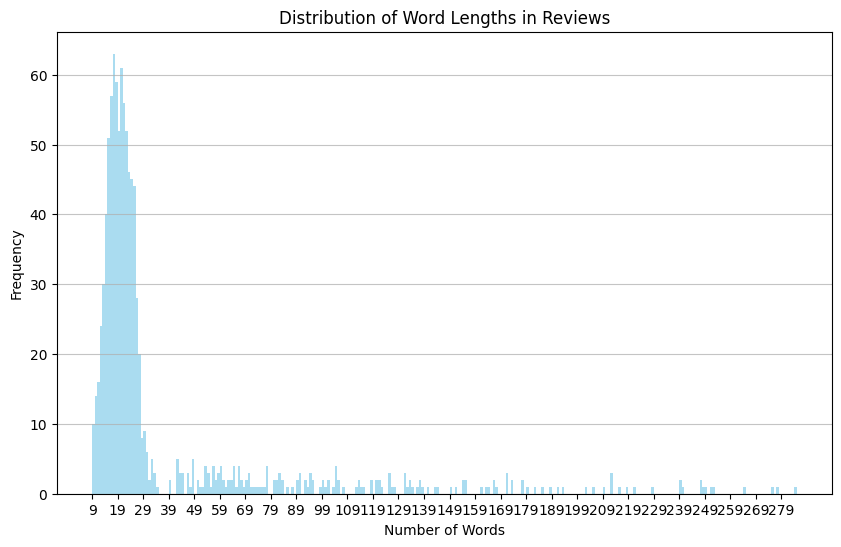

In [53]:
import matplotlib.pyplot as plt
# Plot histogram of word lengths
plt.figure(figsize=(10, 6))
plt.hist(lenghts, bins=range(min(lenghts), max(lenghts)+2), color='skyblue', alpha=0.7)
plt.title('Distribution of Word Lengths in Reviews')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xticks(range(min(lenghts), max(lenghts)+1, 10))
plt.grid(axis='y', alpha=0.75)
plt.show() 

In [62]:
from collections import Counter
# Use .explode() to transform each list item into a separate entry in the Series
# This flattens the list of lists into a single Series of individual words
flat_words = word_tokens.explode()

print("\nFlattened Series of individual words:")
print(flat_words)

# Now, pass the flattened Series to Counter
word_counts = Counter(flat_words)

print("\nWord counts using Counter on the flattened Series:")
print(word_counts)


Flattened Series of individual words:
0       ridiculous
0         mediocre
0              use
0              ava
0         duvernay
          ...     
999          denis
999     villeneuve
999          avoid
999    spectacular
999       failures
Name: review, Length: 37331, dtype: object

Word counts using Counter on the flattened Series:
Counter({'use': 849, 'text': 812, 'default': 805, 'avoid': 805, 'failures': 802, 'character': 275, 'screenplay': 271, 'director': 263, 'actor': 260, 'actress': 254, 'scene': 253, 'cinema': 246, 'plot': 246, 'performance': 242, 'film': 237, 'script': 236, 'movie': 234, 'fantastic': 156, 'boring': 156, 'bad': 153, 'good': 153, 'impressive': 150, 'ridiculous': 147, 'forgettable': 147, 'pointless': 147, 'great': 146, 'terrible': 145, 'excellent': 145, 'enjoyable': 143, 'memorable': 142, 'disappointing': 142, 'moving': 139, 'wonderful': 138, 'masterpiece': 137, 'amazing': 136, 'powerful': 136, 'poor': 135, 'spectacular': 133, 'disaster': 130, 'horrible':

In [66]:
print(f"number of entries in word tokens:{len(word_tokens)}" )
print(f"number of entries in flat words:{len(flat_words)}" )
print(f"number of unique words in flat words:{len(set(flat_words))}" )
print(f"number of unique words in flat words:{len(word_counts)}" )


number of entries in word tokens:1000
number of entries in flat words:37331
number of unique words in flat words:7070
number of unique words in flat words:7070


In [67]:
#2 Most common words in positive and negative reviews
positive_reviews = reviews_df_clean[reviews_df_clean['sentiment'] == 1]['review']
negative_reviews = reviews_df_clean[reviews_df_clean['sentiment'] == 0]['review']
positive_reviews_tokens = positive_reviews.apply(tokenize_text_words)
negative_reviews_tokens = negative_reviews.apply(tokenize_text_words)
flat_words_positive = positive_reviews_tokens.explode()
flat_words_negative = negative_reviews_tokens.explode()
word_counts_positive = Counter(flat_words_positive)
word_counts_negative = Counter(flat_words_negative)
print("\nMost common words in positive reviews:")
print(word_counts_positive.most_common(10))
print("\nMost common words in negative reviews:")
print(word_counts_negative.most_common(10))


Most common words in positive reviews:
[('use', 431), ('text', 412), ('default', 410), ('avoid', 408), ('failures', 408), ('fantastic', 156), ('impressive', 149), ('excellent', 143), ('enjoyable', 143), ('memorable', 142)]

Most common words in negative reviews:
[('use', 418), ('text', 400), ('avoid', 397), ('default', 395), ('failures', 394), ('boring', 154), ('bad', 148), ('ridiculous', 147), ('forgettable', 147), ('pointless', 146)]


The WordCloud class expects a single string of text. If you have a list of words or a pandas Series of words, you'll need to join them into one large string.

Let's use the flat_words Series from our previous discussions as an example. This Series contains all individual words from your reviews.

In [69]:
# Join all words into a single string, separated by spaces
# This is the format the WordCloud generator expects
text_data_positive = " ".join(flat_words_positive.astype(str))
text_data_negative = " ".join(flat_words_negative.astype(str))

print(f"Sample of text_data (first 200 characters): {text_data_positive[:200]}...")
print(f"Sample of text_data (first 200 characters): {text_data_negative[:200]}...")

Sample of text_data (first 200 characters): phenomenal use default text actor wonderful wonderful avoid stunning failures meryl streep remarkable phenomenal good perfect spike lee good use james cameron default actress phenomenal text avatar fa...
Sample of text_data (first 200 characters): ridiculous mediocre use ava duvernay movie default disaster text silence lambs viola davis disaster character inception forgettable avoid horrible worst failures cinema use unbearable script schindler...


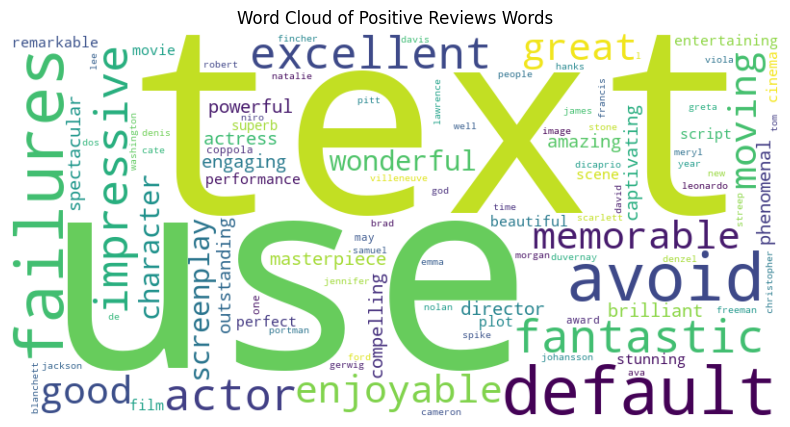

In [71]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Using the 'text_data' string prepared above

# Create a WordCloud object
# You can customize parameters like width, height, background_color, etc.
wordcloud = WordCloud(
    width=800,           # Width of the generated image
    height=400,          # Height of the generated image
    background_color='white', # Background color of the word cloud
    max_words=100,       # Maximum number of words to display
    collocations=False   # Set to False to avoid duplicate bigrams like "new new"
).generate(text_data_positive)    # Generate the word cloud from your text data

# Display the generated image:
plt.figure(figsize=(10, 5)) # Set the figure size
plt.imshow(wordcloud, interpolation='bilinear') # Display the image
plt.axis('off') # Turn off the axis labels and ticks
plt.title('Word Cloud of Positive Reviews Words') # Add a title
plt.show() # Show the plot

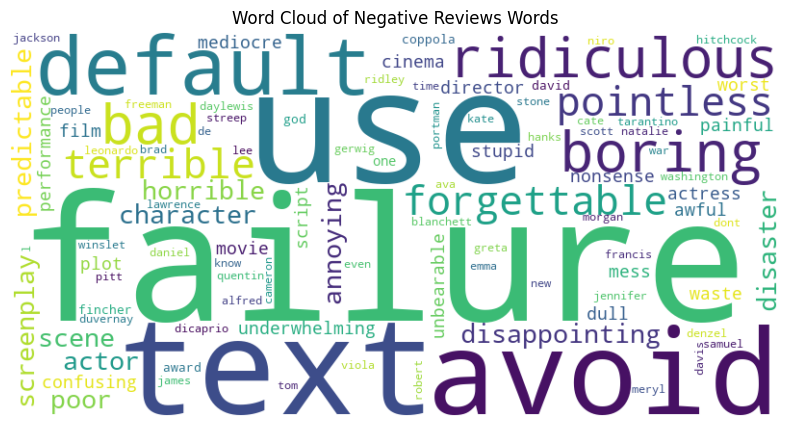

In [72]:
# Create a WordCloud object
# You can customize parameters like width, height, background_color, etc.
wordcloud = WordCloud(
    width=800,           # Width of the generated image
    height=400,          # Height of the generated image
    background_color='white', # Background color of the word cloud
    max_words=100,       # Maximum number of words to display
    collocations=False   # Set to False to avoid duplicate bigrams like "new new"
).generate(text_data_negative)    # Generate the word cloud from your text data

# Display the generated image:
plt.figure(figsize=(10, 5)) # Set the figure size
plt.imshow(wordcloud, interpolation='bilinear') # Display the image
plt.axis('off') # Turn off the axis labels and ticks
plt.title('Word Cloud of Negative Reviews Words') # Add a title
plt.show() # Show the plot

4. Generate and visualize n-gram frequencies (for n=2 and n=3)

In [103]:
from collections import defaultdict
import itertools
import json
unigram_counts = defaultdict(Counter)
unigram_probs = {}

for fw in flat_words:
    for current_word, next_word in itertools.pairwise(fw):
        unigram_counts[current_word][next_word] += 1

for sequence, next_words in unigram_counts.items():
    total_occurrences = sum(next_words.values())
    sequence_probs = {word: count / total_occurrences for word, count in next_words.items()}
    unigram_probs[sequence] = sequence_probs
with open('unigram_probs.json', 'w') as f:
    json.dump(unigram_probs, f, indent=2)


In [140]:
def get_n_grams(words, n):
    """Generate n-grams from a list of words."""
    words = [""]*n
    n_grams_counts = defaultdict(Counter)
    n_grams_probs = {}
    i = 0
    for i in range(len(flat_words)-n):  # Limiting to first 10 entries for demonstration
        words = flat_words[i:n+1+i].to_list()
        n_grams = " ".join(words[0:n])
        n_word = words[n]
        n_grams_counts[n_grams][n_word] += 1
        
    for sequence, next_words in n_grams_counts.items():
        total_occurrences = sum(next_words.values())
        sequence_probs = {word: count / total_occurrences for word, count in next_words.items()}
        n_grams_probs[sequence] = sequence_probs
        
    return n_grams_probs  
    

In [144]:
n=2
bi_gram = get_n_grams(flat_words, n)

with open(f'{n}_grams_probs.json', 'w') as f:
    json.dump(bi_gram, f, indent=2)

In [169]:
n=3
tri_gram = get_n_grams(flat_words, n)

with open(f'{n}_grams_probs.json', 'w') as f:
    json.dump(tri_gram, f, indent=2)

In [171]:
type(bi_gram), type(tri_gram)
bi_gram

{'ridiculous mediocre': {'use': 1.0},
 'mediocre use': {'ava': 0.16666666666666666,
  'worst': 0.16666666666666666,
  'default': 0.3333333333333333,
  'terrible': 0.16666666666666666,
  'character': 0.16666666666666666},
 'use ava': {'duvernay': 1.0},
 'ava duvernay': {'movie': 0.03278688524590164,
  'xfree': 0.01639344262295082,
  'nonsense': 0.01639344262295082,
  'scene': 0.03278688524590164,
  'failure': 0.01639344262295082,
  'pulp': 0.01639344262295082,
  'text': 0.03278688524590164,
  'pointless': 0.01639344262295082,
  'avoid': 0.04918032786885246,
  'screenplay': 0.03278688524590164,
  'bad': 0.01639344262295082,
  'emma': 0.01639344262295082,
  'annual': 0.01639344262295082,
  'use': 0.04918032786885246,
  'entertaining': 0.01639344262295082,
  'director': 0.03278688524590164,
  'natalie': 0.01639344262295082,
  'poor': 0.01639344262295082,
  'powerful': 0.01639344262295082,
  'jennifer': 0.01639344262295082,
  'ridley': 0.01639344262295082,
  'francis': 0.01639344262295082,


In [185]:
def avg(lst):
    """Calculate the average of a list."""
    return sum(lst) / len(lst) if lst else 0

def display_n_grams(n_grams_probs, n_to_display, reverse =True):
    """Display n-grams probabilities."""
    sorted_ngrams = sorted(n_grams_probs.items(), key=lambda x: avg(x[1].values()), reverse=reverse)
    for ngram, probs in sorted_ngrams[:n_to_display]:
        print(f"Sorted N-gram: {ngram}, Probabilities: {probs}") 
    # Plot the n_highest
    categories = [ngram for ngram, _ in sorted_ngrams[:n_to_display]]
    values = [avg(probs.values()) for _, probs in sorted_ngrams[:n_to_display]]
    print(values)
    print(categories)
    plt.figure(figsize=(10, 6))
    plt.bar(categories, values, color='skyblue')
    plt.title(f'Top {n_to_display} N-grams')
    plt.xlabel('N-grams')
    plt.ylabel('Total Probability')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Sorted N-gram: avoid failures, Probabilities: {'phenomenal': 0.004081632653061225, 'archivename': 0.00816326530612245, 'morgan': 0.004081632653061225, 'dont': 0.012244897959183673, 'memorable': 0.00816326530612245, 'leonardo': 0.00816326530612245, 'painful': 0.004081632653061225, 'character': 0.012244897959183673, 'use': 0.23265306122448978, 'worst': 0.004081632653061225, 'placed': 0.004081632653061225, 'director': 0.0163265306122449, 'seems': 0.004081632653061225, 'ri': 0.004081632653061225, 'denzel': 0.004081632653061225, 'godfather': 0.004081632653061225, 'perfect': 0.00816326530612245, 'powerful': 0.00816326530612245, 'script': 0.00816326530612245, 'fantastic': 0.00816326530612245, 'daniel': 0.00816326530612245, 'plot': 0.02040816326530612, 'disaster': 0.004081632653061225, 'forgettable': 0.00816326530612245, 'spike': 0.004081632653061225, 'stupid': 0.004081632653061225, 'compelling': 0.004081632653061225, 'candida': 0.004081632653061225, 'pointless': 0.012244897959183673, 'good': 

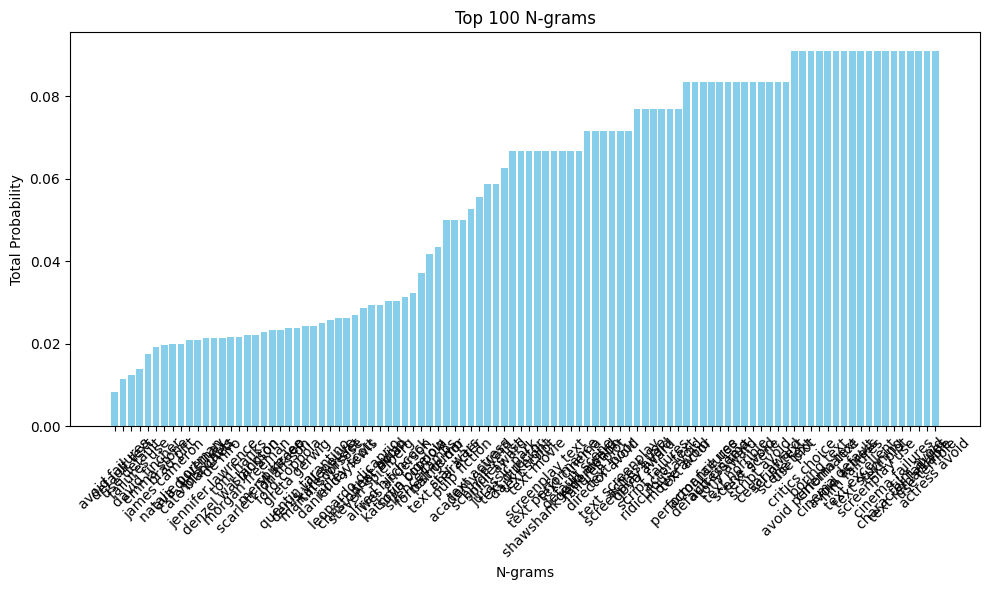

Sorted N-gram: use default text, Probabilities: {'actor': 0.046511627906976744, 'sofia': 0.011627906976744186, 'character': 0.03488372093023256, 'avoid': 0.05813953488372093, 'brilliant': 0.03488372093023256, 'denzel': 0.011627906976744186, 'dull': 0.011627906976744186, 'nonsense': 0.023255813953488372, 'movie': 0.011627906976744186, 'screenplay': 0.023255813953488372, 'engaging': 0.023255813953488372, 'impressive': 0.03488372093023256, 'pointless': 0.023255813953488372, 'beautiful': 0.023255813953488372, 'disappointing': 0.011627906976744186, 'ridiculous': 0.011627906976744186, 'memorable': 0.023255813953488372, 'script': 0.03488372093023256, 'great': 0.011627906976744186, 'superb': 0.011627906976744186, 'cinema': 0.023255813953488372, 'daniel': 0.011627906976744186, 'boring': 0.011627906976744186, 'poor': 0.011627906976744186, 'bafta': 0.011627906976744186, 'david': 0.011627906976744186, 'director': 0.023255813953488372, 'wes': 0.023255813953488372, 'unbearable': 0.011627906976744186

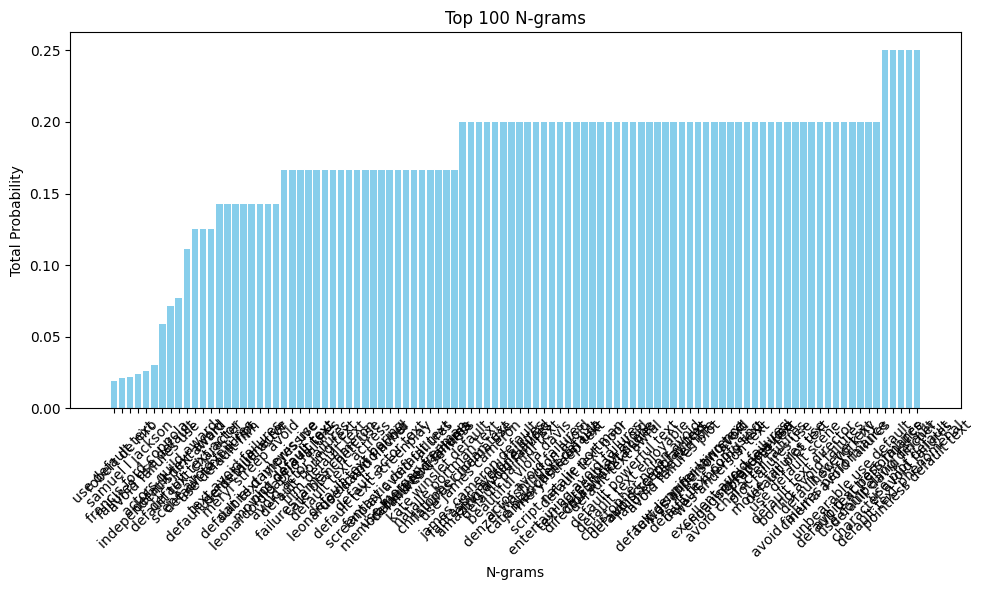

In [186]:
n_display = 100
reverse = False
display_n_grams(bi_gram, n_display, reverse)
display_n_grams(tri_gram, n_display, reverse)

In [187]:
reviews_texts = reviews_df_clean['review'].tolist()
print(f"Number of reviews: {len(reviews_texts)}") 

Number of reviews: 1000


In [189]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF representation
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(reviews_texts)

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
).round(3)

print("TF-IDF representation:")
print(tfidf_df)


TF-IDF representation:
      aa  aaron   ab  abandon  abc  abdel  abilities  ability   able  abolish  \
0    0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
1    0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
2    0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
3    0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
4    0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.041      0.0   
..   ...    ...  ...      ...  ...    ...        ...      ...    ...      ...   
995  0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
996  0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
997  0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
998  0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   
999  0.0    0.0  0.0      0.0  0.0    0.0        0.0      0.0  0.000      0.0   

    

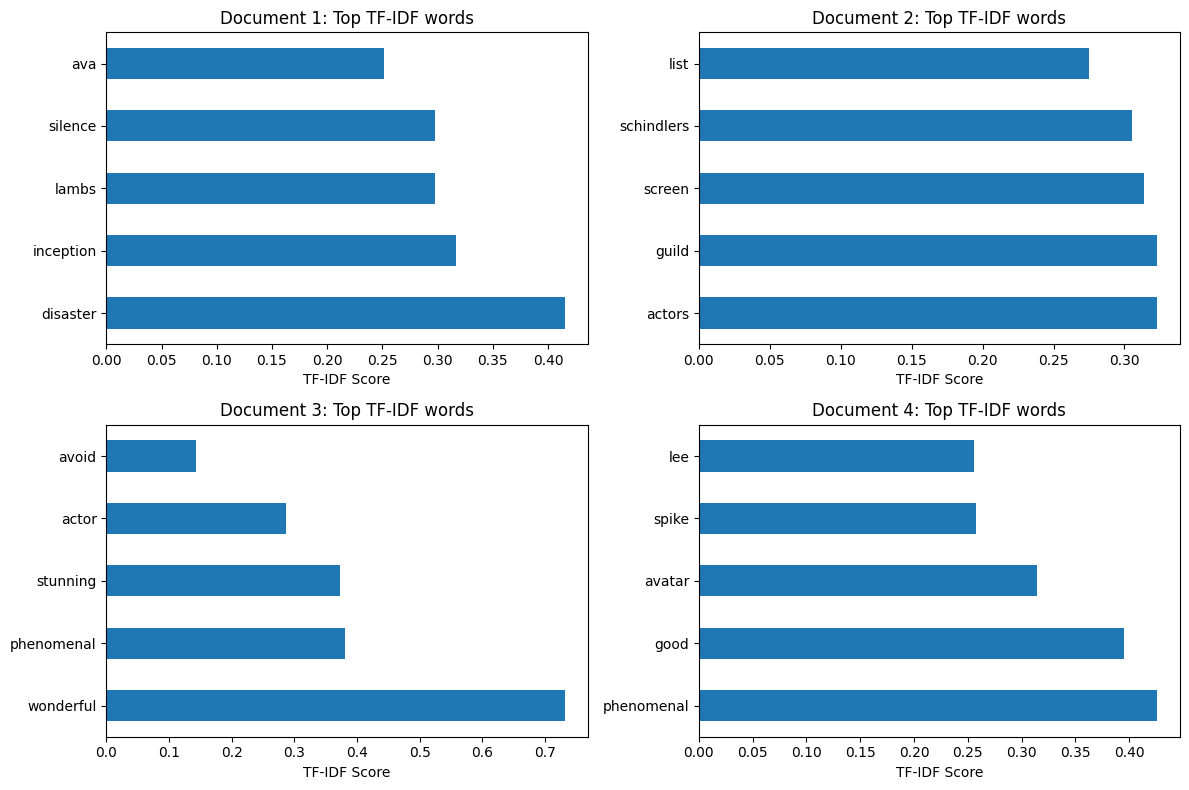

In [190]:
# Visualize important words in each document
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, (doc, ax) in enumerate(zip(reviews_texts, axes)):
    # Get TF-IDF scores for this document
    scores = tfidf_df.iloc[idx]
    top_words = scores.nlargest(5)
    
    # Plot
    top_words.plot(kind='barh', ax=ax)
    ax.set_title(f'Document {idx+1}: Top TF-IDF words')
    ax.set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()

### Task 3: Named Entity Recognition (NER) Exploration (Intermediate)

1. Install and set up NLTK for entity recognition
2. Process a subset of movie reviews (at least 50) with NER and extract all entities
3. Categorize and count entities by type (PERSON, ORGANIZATION, LOCATION, etc.) found in positive vs. negative reviews
4. Create visualizations showing:
   - Distribution of entity types across the dataset
   - Frequency of top 10 entities for each entity type
   - Comparison of entity patterns between positive and negative reviews
5. Implement a custom entity recognition approach for movie-specific entities:
   - Directors (e.g., "Christopher Nolan", "Quentin Tarantino")
   - Actors/Actresses (e.g., "Tom Hanks", "Meryl Streep")
   - Movie titles (hint: look for capitalized phrases and patterns)
   - Awards (e.g., "Oscar", "Golden Globe")
6. Evaluate your custom NER approach on a small manually labeled test set
7. Create a function that takes a review text and returns a highlighted version showing all identified entities with their categories (using different colors or formatting)